
Quantum GAN on MNIST with Anomaly Detection
============================================

Workflow:
  1) Import modules
  2) Load MNIST data (resized to 16×16)
  3) Data preprocessing (including filtering training set to a single “normal” digit)
  4) Implement classical discriminator (PyTorch NN)
  5) Print discriminator diagram (architecture)
  6) Implement quantum generator (patch method using Pennylane)
  7) Print quantum circuit diagram, patch‐method explanation, and math formulas
  8) Training loop (GAN training)
  9) Save models
  10) Print learning rates and related formula
  11) Code for anomaly declaration (anomaly score via reconstruction error)
  12) Plot original image, reconstructed image, and anomaly map with score
  13) Plot training loss curves
  14) Compute & print accuracy table (precision, recall, accuracy)
  15) Display confusion matrix


In [3]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 43.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.0/930.0 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 84.9 MB/s eta 0:00:00:00:0100:01


In [4]:
### 1) IMPORT MODULES ###
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import pennylane as qml

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix


In [6]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
### 2) LOAD MNIST DATA ###
# We resize images to 16x16 so that they can be evenly divided into 4x4 patches.
transform = transforms.Compose([
    transforms.Resize((16, 16)),
    transforms.ToTensor()
])

# Download training and test sets
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

#  For anomaly detection we assume that “normal” images are only digit 1.
normal_digit = 1
mask = train_dataset.targets == normal_digit
train_dataset.data = train_dataset.data[mask]
train_dataset.targets = train_dataset.targets[mask]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)


### 3) (Already performed above: resizing and filtering) ###


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.37MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [8]:
### 4) IMPLEMENT CLASSICAL DISCRIMINATOR ###
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*16, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.model(x)

discriminator = Discriminator().to(device)

In [9]:
### 5) PRINT THE CLASSICAL DISCRIMINATOR DIAGRAM ###
print("=== Classical Discriminator Architecture ===")
print(discriminator)

=== Classical Discriminator Architecture ===
Discriminator(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=128, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


In [10]:
### 6) IMPLEMENT QUANTUM GENERATOR (PATCH METHOD) ###
# We set the following:
patch_size = 4         # each patch is 4x4 pixels
n_qubits   = 4         # we use 4 qubits so that 2^4 = 16, matching the patch pixel count
n_layers   = 2         # number of variational layers
num_patches_per_side = 16 // patch_size  # 16/4 = 4 patches per row (and column)
num_patches = num_patches_per_side ** 2    # total patches per image: 4x4 = 16

# For each patch, we take a latent subvector of dimension equal to the number of qubits.
latent_dim_per_patch = n_qubits
latent_dim = num_patches * latent_dim_per_patch  # overall latent dimension (16*4 = 64)


In [11]:
# Define a Pennylane device:
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(noise_angles, weights):
    """
    Quantum circuit for one patch.
    
    Input:
      noise_angles: Tensor of shape (n_qubits,) used to encode the latent vector
      weights: Tensor of shape (n_layers, n_qubits, 3) used as variational parameters
      
    Circuit:
      1. For each qubit, apply RY(noise_angles[i]) to encode input.
      2. For each layer:
           - Apply a Rot gate (with 3 parameters) to each qubit.
           - Apply a chain of CNOTs to entangle qubits.
      3. Measure the probability distribution over all 2^n_qubits states.
    
    Mathematical Formulation:
      |ψ⟩ = U(weights) [ ⨂_{i=1}^{n_qubits} RY(noise_angles[i]) ] |0⟩^⊗n
      p(x) = |⟨x|ψ⟩|^2  for  x in {0,1}^n.
    """
    # Encode the latent noise into qubit rotations.
    for i in range(n_qubits):
        qml.RY(noise_angles[i], wires=i)
    # Variational layers
    for layer in range(n_layers):
        for i in range(n_qubits):
            qml.Rot(weights[layer, i, 0], weights[layer, i, 1], weights[layer, i, 2], wires=i)
        # Entangling layer: chain of CNOTs
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits - 1, 0])
    return qml.probs(wires=range(n_qubits))

In [12]:
### 7) PRINT THE QUANTUM CIRCUIT DIAGRAM, PATCH DIAGRAM, AND FORMULAS ###
print("\n=== Quantum Circuit Diagram for a Single Patch Generator ===")
# Print the circuit diagram (using dummy inputs)
dummy_noise = torch.zeros(n_qubits)
dummy_weights = torch.zeros((n_layers, n_qubits, 3))
print(qml.draw(quantum_circuit)(dummy_noise, dummy_weights))



=== Quantum Circuit Diagram for a Single Patch Generator ===
0: ──RY(0.00)──Rot(0.00,0.00,0.00)─╭●───────╭X──Rot(0.00,0.00,0.00)─╭●───────╭X─┤ ╭Probs
1: ──RY(0.00)──Rot(0.00,0.00,0.00)─╰X─╭●────│───Rot(0.00,0.00,0.00)─╰X─╭●────│──┤ ├Probs
2: ──RY(0.00)──Rot(0.00,0.00,0.00)────╰X─╭●─│───Rot(0.00,0.00,0.00)────╰X─╭●─│──┤ ├Probs
3: ──RY(0.00)──Rot(0.00,0.00,0.00)───────╰X─╰●──Rot(0.00,0.00,0.00)───────╰X─╰●─┤ ╰Probs


In [14]:
print("""
Explanation:
-------------
Each patch is generated as follows:
1. The latent subvector (of length {}) is encoded via RY rotations.
2. The circuit applies {} layers of variational Rot gates and CNOT entangling gates.
3. The final state |ψ⟩ is measured in the computational basis to yield a probability distribution:
      p(x) = |⟨x|ψ⟩|^2,   x ∈ {{0,1}}^{}.
4. A trainable linear layer maps these {} probabilities to {} pixel intensities (forming a {}x{} patch).
""".format(latent_dim_per_patch, n_layers, n_qubits, 2**n_qubits, patch_size*patch_size, patch_size, patch_size))



Explanation:
-------------
Each patch is generated as follows:
1. The latent subvector (of length 4) is encoded via RY rotations.
2. The circuit applies 2 layers of variational Rot gates and CNOT entangling gates.
3. The final state |ψ⟩ is measured in the computational basis to yield a probability distribution:
      p(x) = |⟨x|ψ⟩|^2,   x ∈ {0,1}^4.
4. A trainable linear layer maps these 16 probabilities to 16 pixel intensities (forming a 4x4 patch).



In [20]:
# Now define the quantum generator module.
class QuantumGenerator(nn.Module):
    def __init__(self):
        super(QuantumGenerator, self).__init__()
        # Trainable parameters for the quantum circuit.
        self.weights = nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 3))
        # A linear layer that maps the quantum circuit output (a vector of length 2^n_qubits)
        # to the patch pixels (patch_size^2 values).
        self.fc = nn.Linear(2**n_qubits, patch_size * patch_size)
    
    def forward(self, z):
        # z: Tensor of shape (batch_size, latent_dim)
        batch_size = z.shape[0]
        patches = []
        # Split the latent vector into sub-vectors for each patch.
        # New shape: (batch_size, num_patches, latent_dim_per_patch)
        z_patches = z.view(batch_size, num_patches, latent_dim_per_patch)
        
        # Process each patch independently.
        for i in range(num_patches):
            patch_batch = []
            for b in range(batch_size):
                noise = z_patches[b, i]  # shape: (n_qubits,)
                # Evaluate the quantum circuit to get a probability vector.
                probs = quantum_circuit(noise, self.weights).float()  # shape: (2**n_qubits,)
                # Map the probabilities to patch pixels.
                patch_val = self.fc(probs)  # shape: (patch_size*patch_size)
                patch_batch.append(patch_val)
            patch_batch = torch.stack(patch_batch)  # shape: (batch_size, patch_size*patch_size)
            patches.append(patch_batch)
        # Stack patches: shape becomes (batch_size, num_patches, patch_size*patch_size)
        patches = torch.stack(patches, dim=1)
        # Apply sigmoid so that output pixel values are in [0,1].
        patches = torch.sigmoid(patches)
        # Reshape each patch to (patch_size, patch_size)
        patches = patches.view(batch_size, num_patches, patch_size, patch_size)
        
        # Reconstruct the full image by arranging patches in a grid.
        images = []
        for b in range(batch_size):
            img_rows = []
            for i in range(num_patches_per_side):
                # Concatenate patches in one row.
                row_patches = patches[b, i*num_patches_per_side:(i+1)*num_patches_per_side]
                row = torch.cat([p for p in row_patches], dim=1)
                img_rows.append(row)
            img = torch.cat(img_rows, dim=0)
            images.append(img)
        images = torch.stack(images)
        # Add a channel dimension so that image shape is (batch_size, 1, H, W)
        images = images.unsqueeze(1)
        return images

quantum_generator = QuantumGenerator().to(device)


In [21]:
print("\n=== Quantum Generator Information ===")
print("Each image (16x16) is divided into {} patches of size {}x{}.".format(num_patches, patch_size, patch_size))
print("The quantum circuit (above) is used to generate each patch from a latent subvector of length {}.".format(latent_dim_per_patch))



=== Quantum Generator Information ===
Each image (16x16) is divided into 16 patches of size 4x4.
The quantum circuit (above) is used to generate each patch from a latent subvector of length 4.


In [22]:
### 8) TRAINING THE GAN ###
# Hyperparameters
num_epochs = 5       # (For a demonstration; increase for better results.)
lr_gan     = 0.0002
beta1      = 0.5
criterion  = nn.BCELoss()

optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_gan, betas=(beta1, 0.999))
optimizer_G = optim.Adam(quantum_generator.parameters(), lr=lr_gan, betas=(beta1, 0.999))

# Lists to record losses
G_losses = []
D_losses = []



In [23]:
print("\n=== Starting GAN Training ===")
for epoch in range(num_epochs):
    for i, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)
        
        # --- Train Discriminator ---
        optimizer_D.zero_grad()
        outputs_real = discriminator(real_imgs)
        loss_real = criterion(outputs_real, real_labels)
        
        # Generate fake images
        z = torch.randn(batch_size, latent_dim, device=device)
        fake_imgs = quantum_generator(z)
        outputs_fake = discriminator(fake_imgs.detach())
        loss_fake = criterion(outputs_fake, fake_labels)
        
        d_loss = loss_real + loss_fake
        d_loss.backward()
        optimizer_D.step()
        
        # --- Train Generator ---
        optimizer_G.zero_grad()
        outputs_fake = discriminator(fake_imgs)
        g_loss = criterion(outputs_fake, real_labels)
        g_loss.backward()
        optimizer_G.step()
        
        if i % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Step [{i}/{len(train_loader)}] "
                  f"D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")
        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())
        
print("=== Training Finished ===")



=== Starting GAN Training ===
Epoch [1/5] Step [0/211] D_loss: 1.3675 G_loss: 0.7563
Epoch [1/5] Step [50/211] D_loss: 0.1965 G_loss: 3.8937
Epoch [1/5] Step [100/211] D_loss: 0.0302 G_loss: 5.6341
Epoch [1/5] Step [150/211] D_loss: 0.0103 G_loss: 6.5967
Epoch [1/5] Step [200/211] D_loss: 0.0037 G_loss: 7.2442
Epoch [2/5] Step [0/211] D_loss: 0.0050 G_loss: 7.3747
Epoch [2/5] Step [50/211] D_loss: 0.0033 G_loss: 7.8509
Epoch [2/5] Step [100/211] D_loss: 0.0021 G_loss: 8.2315
Epoch [2/5] Step [150/211] D_loss: 0.0013 G_loss: 8.5328
Epoch [2/5] Step [200/211] D_loss: 0.0023 G_loss: 8.7583
Epoch [3/5] Step [0/211] D_loss: 0.0008 G_loss: 8.8271
Epoch [3/5] Step [50/211] D_loss: 0.0019 G_loss: 9.0358
Epoch [3/5] Step [100/211] D_loss: 0.0007 G_loss: 9.2126
Epoch [3/5] Step [150/211] D_loss: 0.0007 G_loss: 9.3825
Epoch [3/5] Step [200/211] D_loss: 0.0003 G_loss: 9.5273
Epoch [4/5] Step [0/211] D_loss: 0.0004 G_loss: 9.5620
Epoch [4/5] Step [50/211] D_loss: 0.0002 G_loss: 9.6871
Epoch [4/5] 

In [29]:
### 9) SAVE MODELS ###
torch.save(discriminator.state_dict(), "discriminator_5.pth")
torch.save(quantum_generator.state_dict(), "quantum_generator_5.pth")
print("Models saved to disk.")

Models saved to disk.


In [30]:
### 10) PRINT LEARNING RATES AND NECESSARY FORMULA ###
print("\n=== Learning Rates ===")
for param_group in optimizer_D.param_groups:
    print("Discriminator learning rate:", param_group['lr'])
for param_group in optimizer_G.param_groups:
    print("Generator learning rate:", param_group['lr'])
print("""
Adam Optimizer Bias Correction:
   lr_corrected = lr * sqrt(1 - beta2^t) / (1 - beta1^t)
""")



=== Learning Rates ===
Discriminator learning rate: 0.0002
Generator learning rate: 0.0002

Adam Optimizer Bias Correction:
   lr_corrected = lr * sqrt(1 - beta2^t) / (1 - beta1^t)



In [31]:
### 11) ANOMALY DETECTION CODE ###
# We use a simple reconstruction-based anomaly detector.
# For a given test image x, we try to find the latent vector z* that minimizes:
#      L(z) = || G(z) - x ||^2
# The final loss L(z*) is used as the anomaly score: higher score indicates anomaly.
def compute_anomaly_score(test_img, generator, num_steps=300, lr_anom=0.01):
    """
    Given a test image, optimize over z to minimize the reconstruction error.
    Returns:
      final_loss: the anomaly score (mean squared error)
      recon: the reconstructed image from the optimized z
    """
    generator.eval()
    # Initialize z (with gradient)
    z = torch.randn(1, latent_dim, device=device, requires_grad=True)
    optimizer_z = optim.Adam([z], lr=lr_anom)
    
    for step in range(num_steps):
        optimizer_z.zero_grad()
        recon = generator(z)
        loss = torch.mean((recon - test_img)**2)
        loss.backward()
        optimizer_z.step()
    
    final_loss = loss.item()
    recon = generator(z).detach()
    return final_loss, recon

In [32]:
# For demonstration, we process 100 test images.
anomaly_threshold = 0.02   # This threshold is arbitrary. In practice, tune it on a validation set.
anomaly_scores = []
true_labels = []
pred_labels = []
reconstructions = []
originals = []

In [33]:
print("\n=== Anomaly Detection on Test Images ===")
for idx, (img, label) in enumerate(test_loader):
    if idx >= 10:
        break
    img = img.to(device)
    score, recon = compute_anomaly_score(img, quantum_generator)
    anomaly_scores.append(score)
    originals.append(img.cpu().squeeze().numpy())
    reconstructions.append(recon.cpu().squeeze().numpy())
    
    # In our setup, "normal" images are digit 1.
    true_label = 1 if label.item() == normal_digit else 0
    true_labels.append(true_label)
    pred_label = 1 if score < anomaly_threshold else 0  # lower reconstruction error -> normal
    pred_labels.append(pred_label)
    
    print(f"Test Image {idx}: True Label: {true_label}, Anomaly Score: {score:.4f}, Predicted Label: {pred_label}")



=== Anomaly Detection on Test Images ===
Test Image 0: True Label: 0, Anomaly Score: 0.1074, Predicted Label: 0
Test Image 1: True Label: 0, Anomaly Score: 0.1121, Predicted Label: 0
Test Image 2: True Label: 1, Anomaly Score: 0.1099, Predicted Label: 0
Test Image 3: True Label: 0, Anomaly Score: 0.1250, Predicted Label: 0
Test Image 4: True Label: 0, Anomaly Score: 0.1052, Predicted Label: 0
Test Image 5: True Label: 1, Anomaly Score: 0.1147, Predicted Label: 0
Test Image 6: True Label: 0, Anomaly Score: 0.1051, Predicted Label: 0
Test Image 7: True Label: 0, Anomaly Score: 0.1125, Predicted Label: 0
Test Image 8: True Label: 0, Anomaly Score: 0.1183, Predicted Label: 0
Test Image 9: True Label: 0, Anomaly Score: 0.1159, Predicted Label: 0


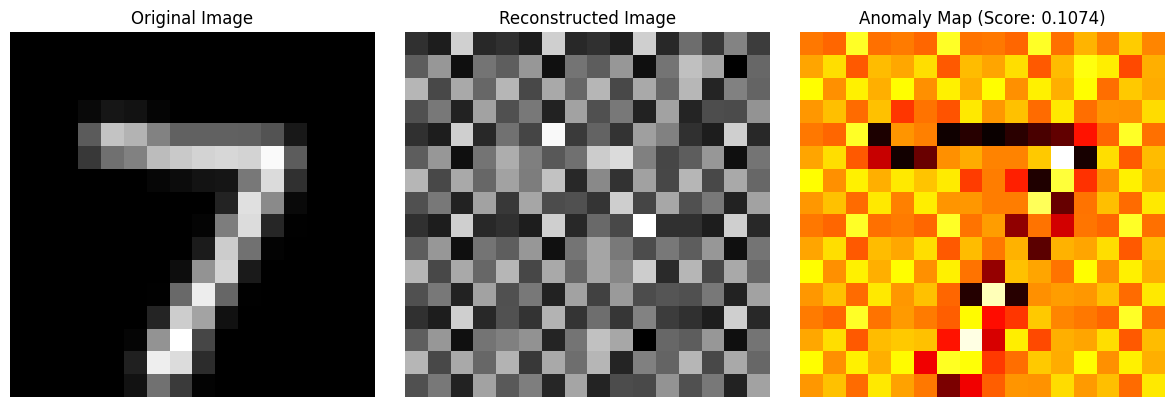

In [34]:

### 12) PLOT ORIGINAL, RECONSTRUCTED, AND ANOMALY MAP ###
# Show the first test example.
idx = 0
original_img = originals[idx]
recon_img = reconstructions[idx]
anomaly_map = np.abs(original_img - recon_img)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(original_img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(recon_img, cmap='gray')
plt.title("Reconstructed Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(anomaly_map, cmap='hot')
plt.title(f"Anomaly Map (Score: {anomaly_scores[idx]:.4f})")
plt.axis("off")
plt.tight_layout()
plt.show()



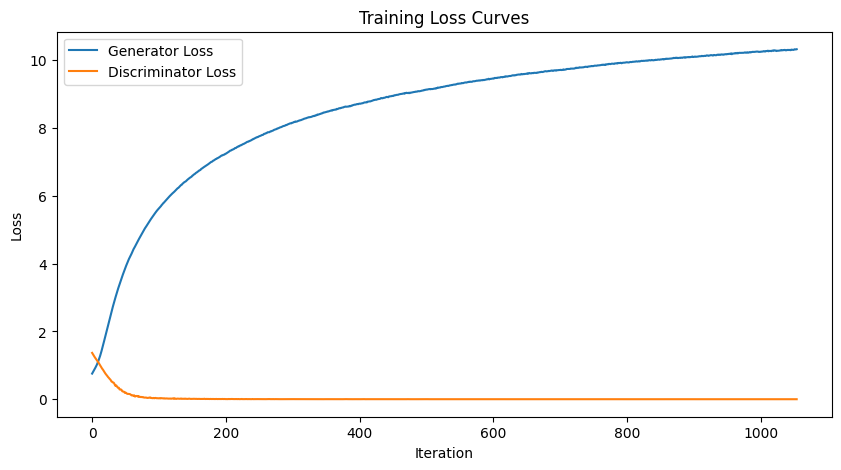

In [35]:
### 13) PLOT TRAINING CURVES ###
plt.figure(figsize=(10,5))
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.show()

In [36]:
### 14) ACCURACY TABLE (PRECISION, RECALL, ACCURACY) ###
precision = precision_score(true_labels, pred_labels)
recall    = recall_score(true_labels, pred_labels)
accuracy  = accuracy_score(true_labels, pred_labels)

print("\n=== Anomaly Detection Performance ===")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Accuracy:  {accuracy:.4f}")


=== Anomaly Detection Performance ===
Precision: 0.0000
Recall:    0.0000
Accuracy:  0.8000


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [37]:
results_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "Accuracy"],
    "Score":  [precision, recall, accuracy]
})
print(results_df)

      Metric  Score
0  Precision    0.0
1     Recall    0.0
2   Accuracy    0.8


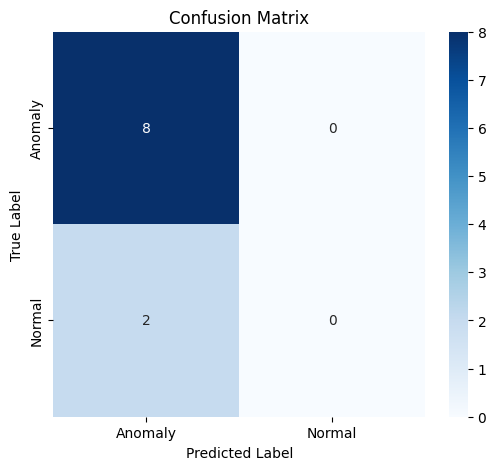

In [38]:
### 15) CONFUSION MATRIX ###
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Anomaly", "Normal"], yticklabels=["Anomaly", "Normal"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()